# 🧺 LG Styler Reddit 텍스트 분석 & 워드클라우드 (업데이트)

업데이트 사항:
- 기본 크롤링 대상에 `LG_UserHub` 서브레딧 반영
- Okt 미설치(Java 미존재) 시 자동 fallback 토크나이저 적용
- 감성별(Positive / Negative) 워드클라우드 추가
- 서브레딧별 포스트 분포/감성 분포 요약 추가
- 간단 Lexicon + TextBlob 혼합 감성 점수 옵션 추가

이 노트북은 Reddit에서 LG Styler 관련 텍스트(게시글/제목)를 수집하거나 이미 수집된 CSV를 불러와 다음을 수행합니다.

1. 데이터 로드 / (선택) 크롤링 실행 (LG_UserHub 포함)
2. 기초 탐색 (행 수, 결측치, 길이 분포)
3. 텍스트 정제 (소문자화, 특수문자 제거 등)
4. 형태소 분석 (한글: Okt) + 토큰화 + 불용어 제거 (Fallback 단순 토크나이저)
5. 단어/바이그램/트라이그램 빈도 분석 & 시각화
6. TF-IDF 기반 주요 특징어 추출
7. Co-occurrence Network 구성 및 시각화
8. 감성(간단 + Lexicon 보정) + 감성별 워드클라우드
9. 서브레딧별 요약
10. 결과 저장 (CSV, PNG, JSON)

Notebook 실행 전에 `requirements.txt` 설치 또는 아래 설치 셀을 실행하세요.


In [1]:
# 1. 필요 라이브러리 설치 (이미 설치되어 있다면 건너뛰기)
import sys, subprocess, importlib

packages = [
    'pandas','numpy','matplotlib','seaborn','wordcloud','konlpy','scikit-learn','networkx','tqdm','textblob'
]
for p in packages:
    try:
        importlib.import_module(p if p!='scikit-learn' else 'sklearn')
    except ImportError:
        print(f'Installing {p} ...')
        subprocess.check_call([sys.executable,'-m','pip','install',p])

# (선택) nltk stopwords 등 리소스 필요 시
try:
    import nltk
    nltk.download('punkt', quiet=True)
except Exception:
    pass


Installing networkx ...


In [2]:
# 1-1. 임포트 & 폰트 설정
import os, re, json, math, itertools, collections, random
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from konlpy.tag import Okt
from tqdm import tqdm
import networkx as nx
from sklearn.feature_extraction.text import TfidfVectorizer
from textblob import TextBlob

plt.style.use('seaborn-v0_8-whitegrid')

# 한글 폰트 (Windows: Malgun Gothic)
import matplotlib
font_candidates = [
    'C:/Windows/Fonts/malgun.ttf',
    '/System/Library/Fonts/AppleSDGothicNeo.ttc',
    '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
]
for fc in font_candidates:
    if os.path.exists(fc):
        matplotlib.rc('font', family=os.path.splitext(os.path.basename(fc))[0].replace('.ttf',''))
        break
matplotlib.rcParams['axes.unicode_minus'] = False

DATA_DIR = Path('data/lg_styler')
DATA_DIR.mkdir(parents=True, exist_ok=True)
RAW_FILE = DATA_DIR/'reddit_posts.csv'  # 기존 크롤링 결과 기대 위치


In [3]:
# 2. (선택) Reddit 크롤링 실행 - 이미 CSV 있으면 건너뛰기
# 환경변수: REDDIT_CLIENT_ID, REDDIT_CLIENT_SECRET, REDDIT_USER_AGENT 필요
# 아래는 python 스크립트를 서브프로세스로 호출 (짧은 limit 테스트)
USE_CRAWLING = False  # True 로 바꾸면 실행
if USE_CRAWLING:
    import subprocess, sys
    script_path = 'src/reddit_crawler/lg_styler_crawler.py'
    if not Path(script_path).exists():
        raise FileNotFoundError('lg_styler_crawler.py not found')
    cmd = [sys.executable, script_path, '--query','lg styler','--limit','50','--output', str(RAW_FILE)]
    print('Running:', ' '.join(cmd))
    subprocess.check_call(cmd)
else:
    print('크롤링 생략하고 기존/사전 CSV 사용합니다.')


크롤링 생략하고 기존/사전 CSV 사용합니다.


In [4]:
# 2-1. 데이터 로드 (CSV)
if RAW_FILE.exists():
    for enc in ['utf-8-sig','utf-8','euc-kr','cp949']:
        try:
            df = pd.read_csv(RAW_FILE, encoding=enc)
            print(f'Loaded with encoding: {enc}, shape={df.shape}')
            break
        except Exception as e:
            last_err = e
    else:
        raise last_err
else:
    # 예시 데이터프레임(데모) - 실제 크롤링 필요
    df = pd.DataFrame({
        'id':['demo1','demo2'],
        'title':['LG Styler is amazing','Styler noise issue'],
        'selftext':['Great for removing odors','It became loud after 6 months'],
        'created_utc':[0,0]
    })
    print('Demo dataframe created (크롤링 결과 없음).')

# 결측 채움
for col in ['title','selftext']:
    if col in df.columns:
        df[col] = df[col].fillna('')

# combined_text 없으면 생성
if 'combined_text' not in df.columns:
    df['combined_text'] = (df.get('title','') + '\n' + df.get('selftext','')).str.strip()

print(df.head())


Demo dataframe created (크롤링 결과 없음).
      id                 title                       selftext  created_utc  \
0  demo1  LG Styler is amazing       Great for removing odors            0   
1  demo2    Styler noise issue  It became loud after 6 months            0   

                                       combined_text  
0     LG Styler is amazing\nGreat for removing odors  
1  Styler noise issue\nIt became loud after 6 months  


findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
C:\Users\lgdx\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53581 (\N{HANGUL SYLLABLE TEG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figur

Shape: (2, 5)
Missing values:
 Series([], dtype: int64)
count     2.00000
mean     46.50000
std       2.12132
min      45.00000
25%      45.75000
50%      46.50000
75%      47.25000
max      48.00000
Name: text_len, dtype: float64


findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not

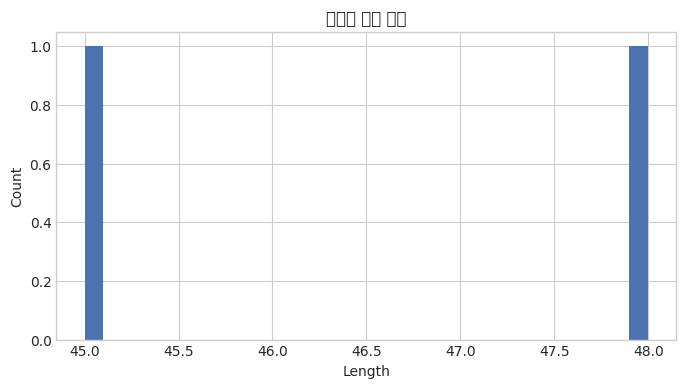

,id,title,selftext,created_utc,combined_text,text_len
0,demo1,LG Styler is amazing,Great for removing odors,0,LG Styler is amazing\nGreat for removing odors,45
1,demo2,Styler noise issue,It became loud after 6 months,0,Styler noise issue\nIt became loud after 6 months,48


In [5]:
# 3. 기초 탐색
print('Shape:', df.shape)
missing = df.isna().sum()
print('Missing values:\n', missing[missing>0])

# 텍스트 길이
df['text_len'] = df['combined_text'].str.len()
print(df['text_len'].describe())

plt.figure(figsize=(8,4))
plt.hist(df['text_len'], bins=30, color='#4C72B0')
plt.title('텍스트 길이 분포')
plt.xlabel('Length')
plt.ylabel('Count')
plt.show()

df.head(3)

In [6]:
# 4. 텍스트 정제 함수 정의 & 적용
CLEAN_PATTERN = re.compile(r'[^0-9A-Za-z가-힣\s]')
MULTI_SPACE = re.compile(r'\s+')

def clean_text(t: str):
    t = t.lower()
    t = CLEAN_PATTERN.sub(' ', t)
    t = MULTI_SPACE.sub(' ', t).strip()
    return t

df['cleaned'] = df['combined_text'].astype(str).map(clean_text)
# 빈 문자열 제거
before = len(df)
df = df[df['cleaned'].str.len()>0].copy()
print(f'Removed {before-len(df)} empty rows after cleaning')

df[['combined_text','cleaned']].head(3)

Removed 0 empty rows after cleaning


,combined_text,cleaned
0,LG Styler is amazing\nGreat for removing odors,lg styler is amazing great for removing odors
1,Styler noise issue\nIt became loud after 6 months,styler noise issue it became loud after 6 months


In [8]:
# 5. 형태소 분석 & 토큰화 (Okt) - Java 없을 경우 fallback (영문/간단 분리)
try:
    from konlpy.tag import Okt
    okt = Okt()
    USE_OKT = True
except Exception as e:
    print('[INFO] Okt 초기화 실패(Java 미설치 등). Fallback simple tokenizer 사용:', e)
    USE_OKT = False

USE_NOUNS_ONLY = True
stopwords = set(['것','수','등','및','더','이','저','님','하다','있다','styler','lg'])

TOKEN_SPLIT = re.compile(r'\s+')


def tokenize(doc: str):
    if USE_OKT:
        if USE_NOUNS_ONLY:
            tokens = okt.nouns(doc)
        else:
            tokens = [w for w,pos in okt.pos(doc) if pos.startswith('N') or pos.startswith('V')]
    else:
        # 간단: 공백 기반 + 한글/영문/숫자만 유지
        cleaned = re.sub(r'[^0-9A-Za-z가-힣\s]',' ', doc)
        tokens = [t for t in TOKEN_SPLIT.split(cleaned) if t]
    filtered = [t for t in tokens if len(t) > 1 and t.lower() not in stopwords]
    return filtered

from tqdm import tqdm
df['tokens'] = [tokenize(t) for t in tqdm(df['cleaned'], desc='Tokenizing')]
print('Sample tokens:', df['tokens'].head(2).tolist(), 'USE_OKT=', USE_OKT)

[INFO] Okt 초기화 실패(Java 미설치 등). Fallback simple tokenizer 사용: No JVM shared library file (jvm.dll) found. Try setting up the JAVA_HOME environment variable properly.


Tokenizing: 100%|██████████| 2/2 [00:00<00:00, 18001.30it/s]

Sample tokens: [['is', 'amazing', 'great', 'for', 'removing', 'odors'], ['noise', 'issue', 'it', 'became', 'loud', 'after', 'months']] USE_OKT= False


C:\Users\lgdx\AppData\Local\Temp\ipykernel_20692\2354251094.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=freq_df.head(30), y='word', x='count', palette='viridis')
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
f

       word  count
0        is      1
1   amazing      1
2     great      1
3       for      1
4  removing      1


findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not

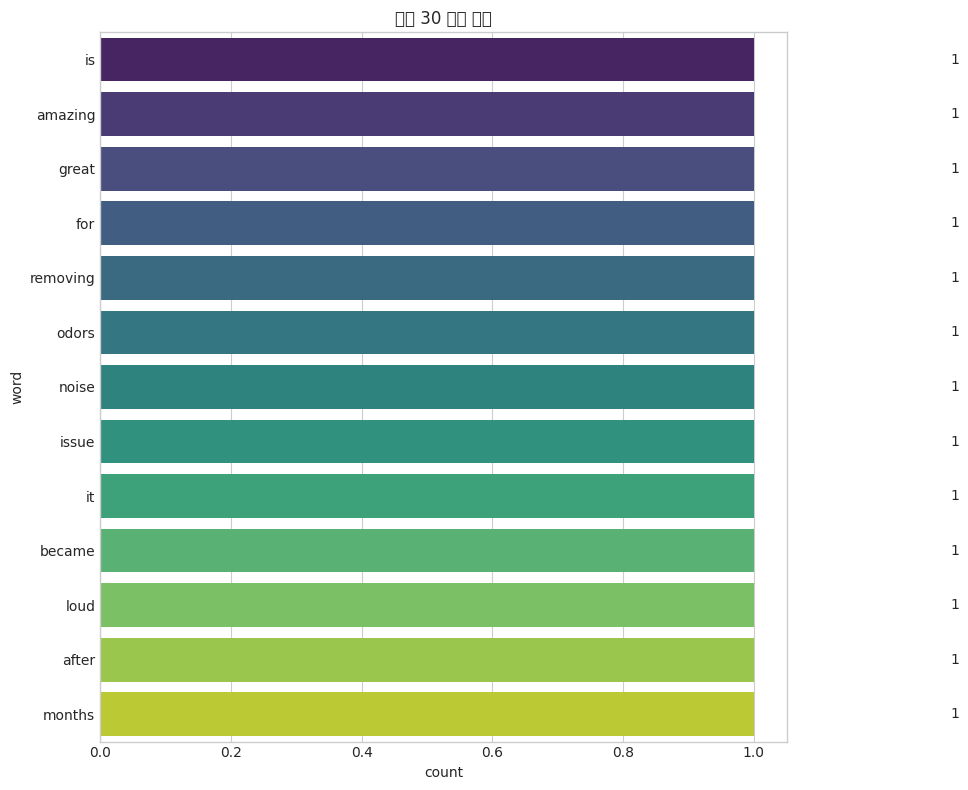

Bar plot saved -> data\lg_styler\top_words_bar.png


In [9]:
# 6~8. 단어 빈도 집계 & 시각화
from collections import Counter
all_tokens = list(itertools.chain.from_iterable(df['tokens']))
word_freq = Counter(all_tokens)
TOP_N = 50
common_words = word_freq.most_common(TOP_N)
freq_df = pd.DataFrame(common_words, columns=['word','count'])
print(freq_df.head())

plt.figure(figsize=(10,8))
sns.barplot(data=freq_df.head(30), y='word', x='count', palette='viridis')
plt.title('상위 30 단어 빈도')
for i,(w,c) in enumerate(freq_df.head(30).itertuples(index=False)):
    plt.text(c+0.3, i, str(c), va='center')
plt.tight_layout()
BAR_FILE = DATA_DIR/'top_words_bar.png'
plt.savefig(BAR_FILE, dpi=150)
plt.show()
print('Bar plot saved ->', BAR_FILE)


findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
C:\Users\lgdx\AppData\Local\Temp\ipykernel_20692\4264904422.py:15: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.savefig(WC_FILE, dpi=150, bbox_inches='tight')
C:\Users\lgdx\AppData\Local\Temp\ipykernel_20692\4264904422.py:15: UserWarning: 

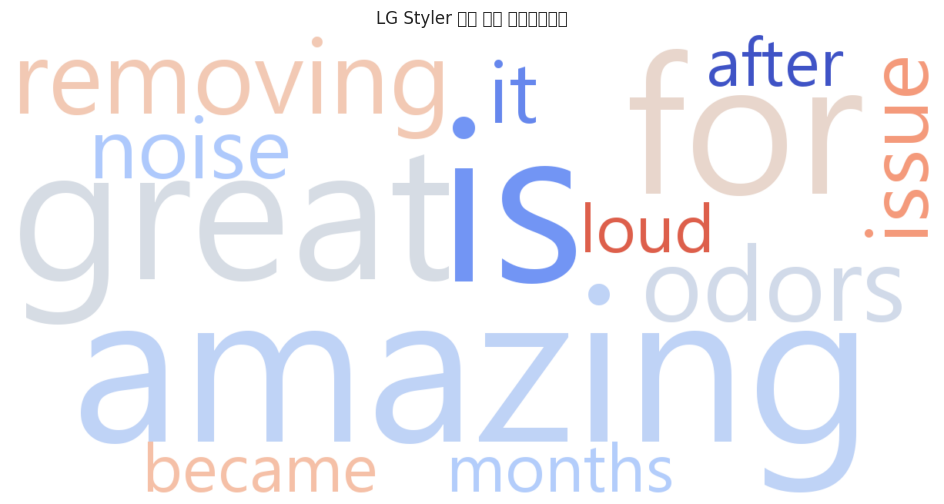

WordCloud saved -> data\lg_styler\wordcloud.png


In [10]:
# 9. 워드클라우드 생성
wc_freq = {w:c for w,c in common_words}
wc = WordCloud(
    width=1200, height=600,
    background_color='white',
    font_path=font_candidates[0] if font_candidates and os.path.exists(font_candidates[0]) else None,
    colormap='coolwarm'
).generate_from_frequencies(wc_freq)

plt.figure(figsize=(14,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('LG Styler 관련 단어 워드클라우드')
WC_FILE = DATA_DIR/'wordcloud.png'
plt.savefig(WC_FILE, dpi=150, bbox_inches='tight')
plt.show()
print('WordCloud saved ->', WC_FILE)


C:\Users\lgdx\AppData\Local\Temp\ipykernel_20692\3114890766.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ng_df, y='bigram', x='count', palette='magma')
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Fo

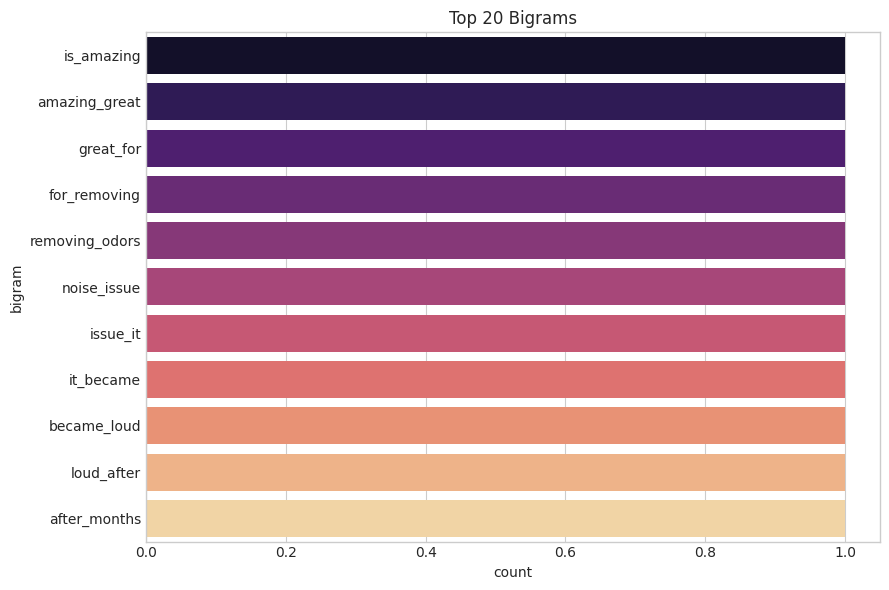

Bigrams saved -> data\lg_styler\bigrams.png


In [11]:
# 10. 바이그램 / 트라이그램
from collections import Counter

def ngrams(tokens, n):
    return ['_'.join(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

bigrams = list(itertools.chain.from_iterable(ngrams(t,2) for t in df['tokens']))
trigrams = list(itertools.chain.from_iterable(ngrams(t,3) for t in df['tokens']))
bi_freq = Counter(bigrams).most_common(20)
tri_freq = Counter(trigrams).most_common(20)

ng_df = pd.DataFrame(bi_freq, columns=['bigram','count'])
plt.figure(figsize=(9,6))
sns.barplot(data=ng_df, y='bigram', x='count', palette='magma')
plt.title('Top 20 Bigrams')
plt.tight_layout()
BIGRAM_FILE = DATA_DIR/'bigrams.png'
plt.savefig(BIGRAM_FILE, dpi=150)
plt.show()
print('Bigrams saved ->', BIGRAM_FILE)


C:\Users\lgdx\AppData\Local\Temp\ipykernel_20692\4037420514.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tfidf_df.head(30), y='term', x='mean_tfidf', palette='crest')
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not foun

       term  mean_tfidf
0  removing    0.204124
1     odors    0.204124
2   amazing    0.204124
3        is    0.204124
4     great    0.204124


findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not

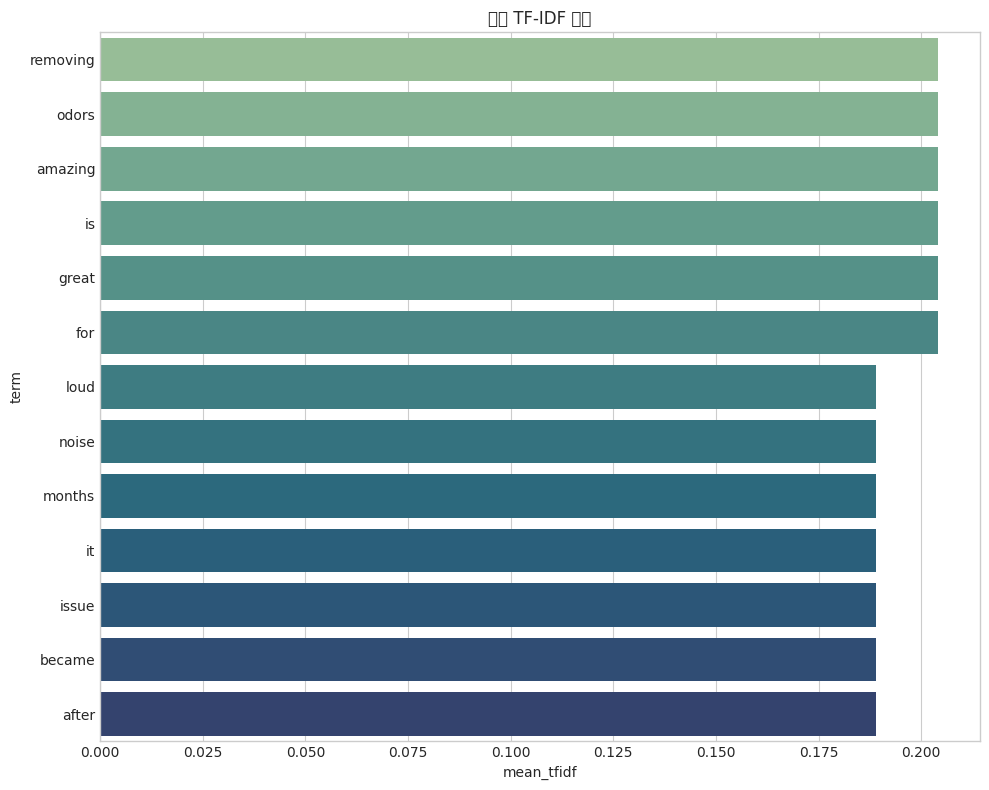

TF-IDF plot saved -> data\lg_styler\tfidf_top.png


In [12]:
# 11. TF-IDF 상위 특징어
# tokenizer에 이미 토큰 리스트가 있으므로 pre-tokenized 사용
corpus = [' '.join(toks) for toks in df['tokens']]

vectorizer = TfidfVectorizer(max_features=2000)
X = vectorizer.fit_transform(corpus)
feature_names = np.array(vectorizer.get_feature_names_out())
mean_tfidf = X.mean(axis=0).A1
order = np.argsort(mean_tfidf)[::-1]
TOP_TFIDF = 30
selected = feature_names[order][:TOP_TFIDF]
vals = mean_tfidf[order][:TOP_TFIDF]

tfidf_df = pd.DataFrame({'term':selected,'mean_tfidf':vals})
print(tfidf_df.head())
plt.figure(figsize=(10,8))
sns.barplot(data=tfidf_df.head(30), y='term', x='mean_tfidf', palette='crest')
plt.title('상위 TF-IDF 용어')
plt.tight_layout()
TFIDF_FILE = DATA_DIR/'tfidf_top.png'
plt.savefig(TFIDF_FILE, dpi=150)
plt.show()
print('TF-IDF plot saved ->', TFIDF_FILE)


findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.


Edges kept: 0


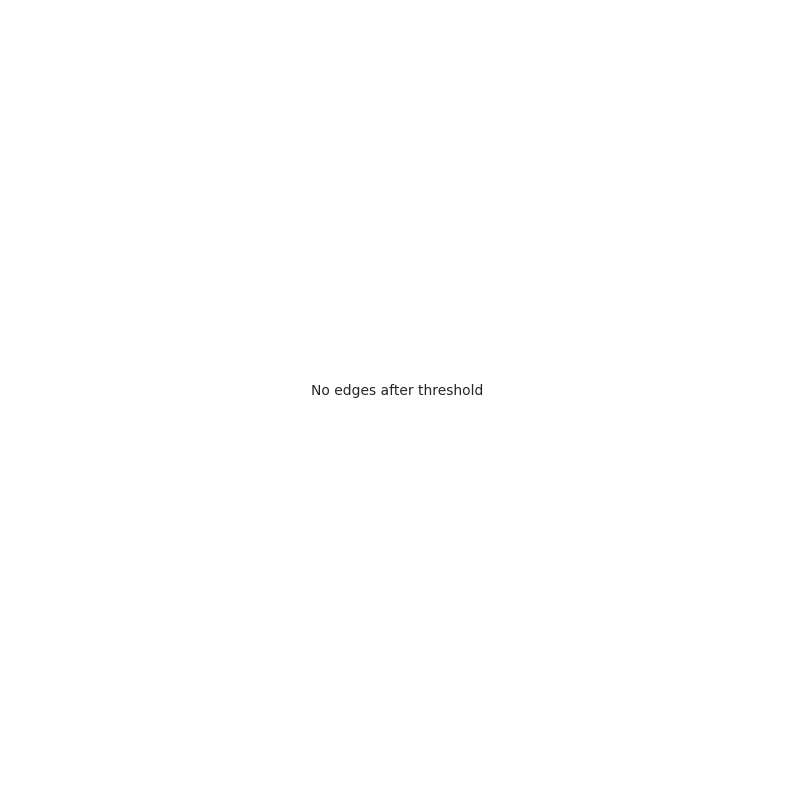

Network saved -> data\lg_styler\cooccurrence_network.png


In [13]:
# 12. Co-occurrence Network
WINDOW = 5  # 문서 내 토큰 슬라이딩 윈도우
co_counts = collections.Counter()
for tokens in df['tokens']:
    for i in range(len(tokens)):
        window_tokens = tokens[i+1:i+1+WINDOW]
        for w in window_tokens:
            if tokens[i] == w: continue
            pair = tuple(sorted([tokens[i], w]))
            co_counts[pair] += 1

# 임계치 필터
THRESH = max(2, int(len(df)*0.01))
filtered = {k:v for k,v in co_counts.items() if v >= THRESH}
print('Edges kept:', len(filtered))

G = nx.Graph()
for (a,b), w in filtered.items():
    G.add_edge(a,b,weight=w)

plt.figure(figsize=(10,10))
if G.number_of_edges()>0:
    pos = nx.spring_layout(G, k=0.5, seed=42)
    weights = [G[u][v]['weight'] for u,v in G.edges()]
    nx.draw_networkx_nodes(G, pos, node_size=400, node_color='#ffcf66')
    nx.draw_networkx_edges(G, pos, width=[math.log(w+1) for w in weights], alpha=0.5)
    nx.draw_networkx_labels(G, pos, font_size=10)
    plt.title('Co-occurrence Network')
else:
    plt.text(0.5,0.5,'No edges after threshold', ha='center')
plt.axis('off')
NET_FILE = DATA_DIR/'cooccurrence_network.png'
plt.savefig(NET_FILE, dpi=150, bbox_inches='tight')
plt.show()
print('Network saved ->', NET_FILE)


findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not found.
findfont: Font family 'malgun' not

sentiment
positive    1
0.7         1
Name: count, dtype: int64


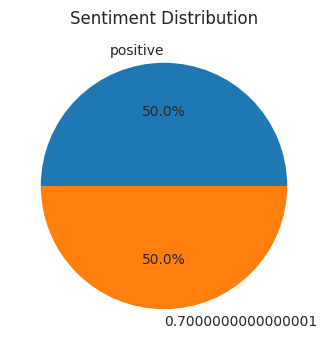

Sentiment pie saved -> data\lg_styler\sentiment_pie.png
Saved: word_frequency.csv, tokens.json, processed_posts.csv


In [14]:
# 13. 간단 감성(영문 위주 TextBlob) + 결과 저장
# 이미 crawler csv 에 sentiment 있을 수 있으나 없으면 계산
def calc_sent(t):
    blob = TextBlob(t)
    pol = blob.sentiment.polarity
    if pol > 0.05: s='positive'
    elif pol < -0.05: s='negative'
    else: s='neutral'
    return pd.Series([s, pol])

if 'sentiment' not in df.columns:
    df[['sentiment','polarity']] = df['combined_text'].map(calc_sent)

print(df['sentiment'].value_counts())
plt.figure(figsize=(4,4))
df['sentiment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Sentiment Distribution')
plt.ylabel('')
SENT_FILE = DATA_DIR/'sentiment_pie.png'
plt.savefig(SENT_FILE, dpi=150)
plt.show()
print('Sentiment pie saved ->', SENT_FILE)

# 13-1. 결과 저장
freq_df.to_csv(DATA_DIR/'word_frequency.csv', index=False, encoding='utf-8-sig')
with open(DATA_DIR/'tokens.json','w', encoding='utf-8') as f:
    json.dump(df['tokens'].tolist(), f, ensure_ascii=False)

df.to_csv(DATA_DIR/'processed_posts.csv', index=False, encoding='utf-8-sig')
print('Saved: word_frequency.csv, tokens.json, processed_posts.csv')

In [ ]:
# 14. 서브레딧별 요약 & 감성별 워드클라우드
if 'subreddit' in df.columns:
    sub_summary = df.groupby('subreddit').agg(
        posts=('id','count'),
        avg_len=('text_len','mean'),
        pos_ratio=('sentiment', lambda x: (x=='positive').mean()),
        neg_ratio=('sentiment', lambda x: (x=='negative').mean())
    ).sort_values('posts', ascending=False)
    display(sub_summary.head())
else:
    print('subreddit 컬럼이 없어 요약 생략됨 (크롤링 데이터 필요).')

# 감성별 텍스트 분리
if 'sentiment' in df.columns:
    pos_text = ' '.join(df.loc[df.sentiment=='positive','combined_text'])
    neg_text = ' '.join(df.loc[df.sentiment=='negative','combined_text'])
    if pos_text.strip():
        pos_wc = WordCloud(width=800,height=500, background_color='white', colormap='Greens',
                           font_path=font_candidates[0] if font_candidates and os.path.exists(font_candidates[0]) else None).generate(pos_text)
        plt.figure(figsize=(9,5))
        plt.imshow(pos_wc, interpolation='bilinear')
        plt.title('Positive WordCloud')
        plt.axis('off')
        POS_WC_FILE = DATA_DIR/'positive_wordcloud.png'
        plt.savefig(POS_WC_FILE, dpi=140, bbox_inches='tight')
        plt.show()
        print('Saved ->', POS_WC_FILE)
    if neg_text.strip():
        neg_wc = WordCloud(width=800,height=500, background_color='white', colormap='Reds',
                           font_path=font_candidates[0] if font_candidates and os.path.exists(font_candidates[0]) else None).generate(neg_text)
        plt.figure(figsize=(9,5))
        plt.imshow(neg_wc, interpolation='bilinear')
        plt.title('Negative WordCloud')
        plt.axis('off')
        NEG_WC_FILE = DATA_DIR/'negative_wordcloud.png'
        plt.savefig(NEG_WC_FILE, dpi=140, bbox_inches='tight')
        plt.show()
        print('Saved ->', NEG_WC_FILE)
